# Task 2: Credit Risk Prediction

## Research Purpose

This notebook studies a loan-application dataset from the point of view of a lending analyst. The practical question is not just "can we predict approval?" but "which applicant and loan characteristics appear connected with approval decisions, and how reliable is a first scoring model?"

I am careful with the wording because this dataset records loan status, not verified repayment/default history. In the analysis below, `Loan_Status = Y` is treated as an approved or lower-risk outcome, while `Loan_Status = N` is treated as a not-approved or higher-risk outcome. That keeps the business interpretation useful without pretending the data contains information it does not.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette=["#264653", "#E76F51", "#2A9D8F", "#F4A261"],
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    },
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## Dataset Loading and First Look

In [2]:
local_path = DATA_DIR / "train_u6lujuX_CVtuZ9i.csv"
if not local_path.exists():
    raise FileNotFoundError(
        f"Expected local dataset at {local_path}. Place train_u6lujuX_CVtuZ9i.csv in data/raw."
    )

raw_df = pd.read_csv(local_path)

print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]:,}")
raw_df.head()

Rows: 614
Columns: 13


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Research note:** This is a compact application dataset. It mixes numeric fields such as income and loan amount with categorical fields such as gender, education, employment status, property area, and credit history. The target is the lender's recorded decision.

In [3]:
quality_report = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "missing_values": raw_df.isna().sum(),
        "missing_rate": raw_df.isna().mean(),
        "unique_values": raw_df.nunique(dropna=True),
    }
).sort_values(["missing_values", "unique_values"], ascending=[False, False])

display(quality_report)
display(raw_df["Loan_Status"].value_counts().rename("loan_status_count"))
display(raw_df["Loan_Status"].value_counts(normalize=True).rename("loan_status_rate").round(3))

,dtype,missing_values,missing_rate,unique_values
Credit_History,float64,50,0.081433,2
Self_Employed,object,32,0.052117,2
LoanAmount,float64,22,0.035831,203
Dependents,object,15,0.024430,4
Loan_Amount_Term,float64,14,0.022801,10
Gender,object,13,0.021173,2
Married,object,3,0.004886,2
Loan_ID,object,0,0.000000,614
ApplicantIncome,int64,0,0.000000,505
CoapplicantIncome,float64,0,0.000000,287


Loan_Status
Y    422
N    192
Name: loan_status_count, dtype: int64

Loan_Status
Y    0.687
N    0.313
Name: loan_status_rate, dtype: float64

## Cleaning, Feature Setup, and Target Definition

In [4]:
df = raw_df.copy()
df = df.drop(columns=["Loan_ID"], errors="ignore")

df["loan_approved"] = df["Loan_Status"].map({"Y": 1, "N": 0})
df = df.drop(columns=["Loan_Status"])

target = "loan_approved"
numeric_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
]
categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
]

for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df["LoanAmount_to_TotalIncome"] = df["LoanAmount"] / df["TotalIncome"].replace(0, np.nan)
df["Has_Coapplicant_Income"] = (df["CoapplicantIncome"] > 0).astype(int)

engineered_numeric = numeric_features + [
    "TotalIncome",
    "LoanAmount_to_TotalIncome",
    "Has_Coapplicant_Income",
]

X = df[engineered_numeric + categorical_features]
y = df[target]

display(X.head())
print(f"Positive class rate (approved/lower risk): {y.mean():.3f}")

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,LoanAmount_to_TotalIncome,Has_Coapplicant_Income,Gender,Married,Dependents,Education,Self_Employed,Property_Area
0,5849,0.0,NaN,360.0,1.0,5849.0,NaN,0,Male,No,0,Graduate,No,Urban
1,4583,1508.0,128.0,360.0,1.0,6091.0,0.021015,1,Male,Yes,1,Graduate,No,Rural
2,3000,0.0,66.0,360.0,1.0,3000.0,0.022000,0,Male,Yes,0,Graduate,Yes,Urban
3,2583,2358.0,120.0,360.0,1.0,4941.0,0.024287,1,Male,Yes,0,Not Graduate,No,Urban
4,6000,0.0,141.0,360.0,1.0,6000.0,0.023500,0,Male,No,0,Graduate,No,Urban


Positive class rate (approved/lower risk): 0.687


## Descriptive Statistical Analytics

In [5]:
numeric_summary = (
    df.groupby(target)[engineered_numeric]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

numeric_summary

ApplicantIncome                           CoapplicantIncome  \
                        count     mean  median      std             count   
loan_approved                                                               
0                         192  5446.08  3833.5  6819.56               192   
1                         422  5384.07  3812.5  5765.44               422   

                                        LoanAmount          ... TotalIncome  \
                  mean  median      std      count    mean  ...      median   
loan_approved                                               ...               
0              1877.81   268.0  4384.06        181  151.22  ...      5289.5   
1              1504.52  1239.5  1924.75        411  144.29  ...      5439.0   

                       LoanAmount_to_TotalIncome                     \
                   std                     count  mean median   std   
loan_approved                                                         
0              7739.77                       181  0.02   0.02  0.01   
1              5788.06                       411  0.02   0.02  0.01   

              Has_Coapplicant_Income                     
                               count  mean median   std  
loan_approved                                            
0                                192  0.50    0.5  0.50  
1                                422  0.58    1.0  0.49  

[2 rows x 32 columns]

In [6]:
approval_by_credit = (
    df.groupby("Credit_History")[target]
    .agg(applications="count", approval_rate="mean")
    .reset_index()
    .sort_values("Credit_History")
)

approval_by_property = (
    df.groupby("Property_Area")[target]
    .agg(applications="count", approval_rate="mean")
    .sort_values("approval_rate", ascending=False)
)

display(approval_by_credit.round(3))
display(approval_by_property.round(3))

,Credit_History,applications,approval_rate
0,0.0,89,0.079
1,1.0,475,0.796


,applications,approval_rate
Property_Area,,
Semiurban,233,0.768
Urban,202,0.658
Rural,179,0.615


**Research note:** Credit history is the first variable I would review with a lender. It is usually much more decision-relevant than raw income alone. Income still matters, but a higher income does not automatically mean approval when credit history, loan size, and missing documentation are part of the picture.

## Exploratory Visual Analytics

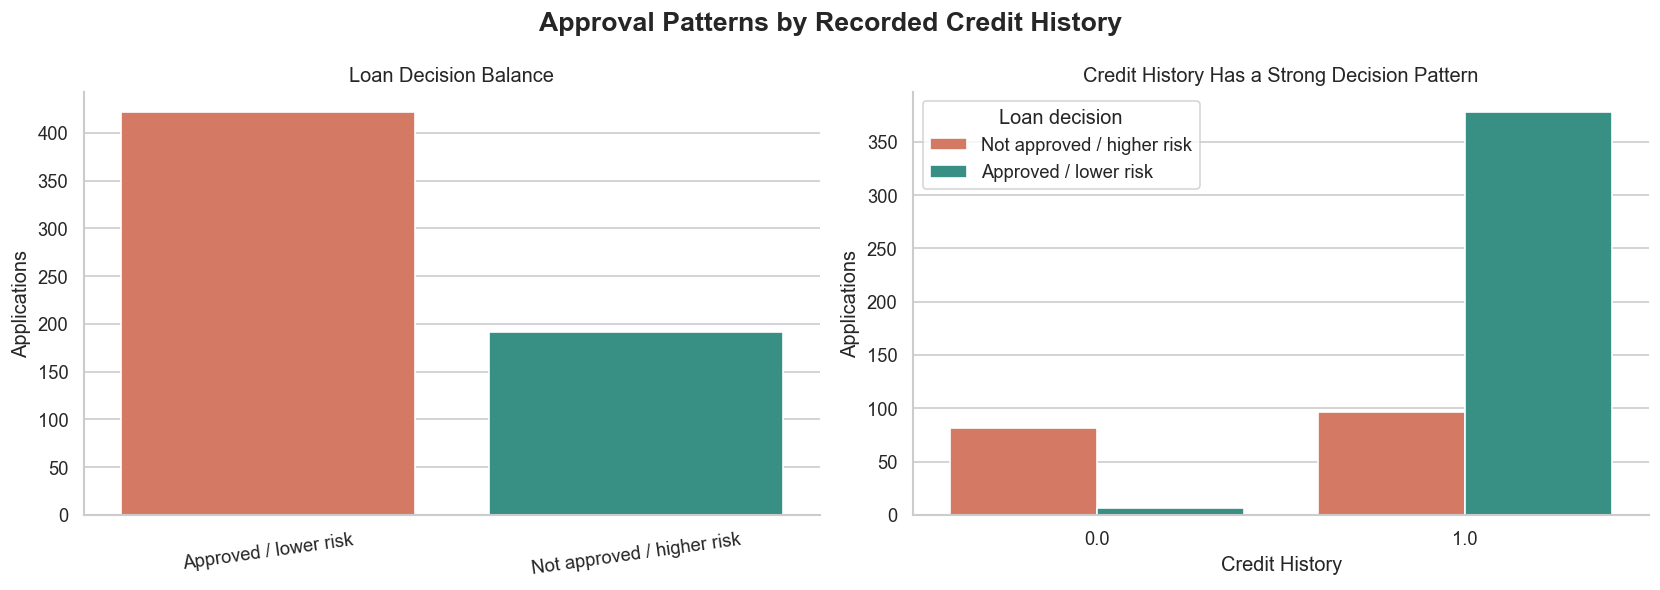

In [7]:
plot_df = df.copy()
plot_df["Loan decision"] = plot_df[target].map({0: "Not approved / higher risk", 1: "Approved / lower risk"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=plot_df, x="Loan decision", ax=axes[0], palette=["#E76F51", "#2A9D8F"])
axes[0].set_title("Loan Decision Balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Applications")
axes[0].tick_params(axis="x", rotation=8)

sns.countplot(data=plot_df, x="Credit_History", hue="Loan decision", ax=axes[1], palette=["#E76F51", "#2A9D8F"])
axes[1].set_title("Credit History Has a Strong Decision Pattern")
axes[1].set_xlabel("Credit History")
axes[1].set_ylabel("Applications")

fig.suptitle("Approval Patterns by Recorded Credit History", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task2_status_and_credit_history.png", dpi=180, bbox_inches="tight")
plt.show()

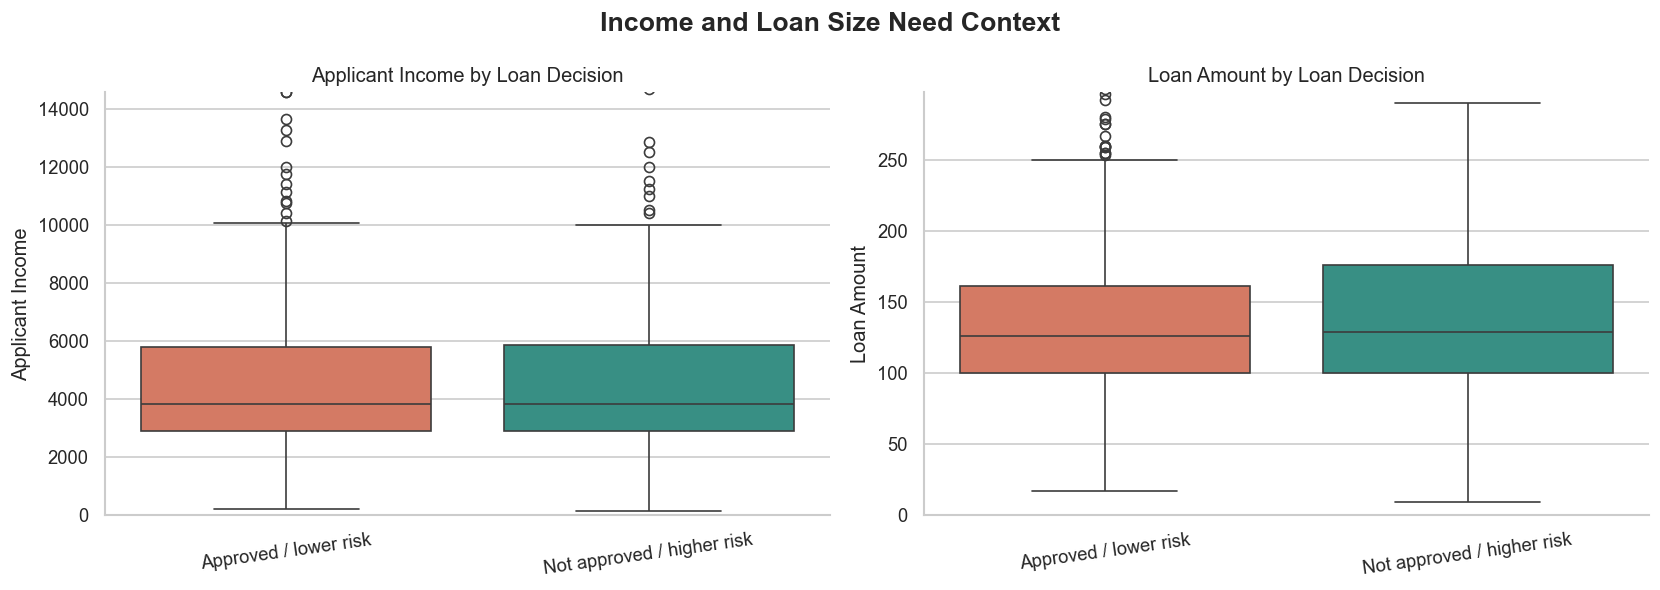

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_df, x="Loan decision", y="ApplicantIncome", ax=axes[0], palette=["#E76F51", "#2A9D8F"])
axes[0].set_ylim(0, df["ApplicantIncome"].quantile(0.95))
axes[0].set_title("Applicant Income by Loan Decision")
axes[0].set_xlabel("")
axes[0].set_ylabel("Applicant Income")
axes[0].tick_params(axis="x", rotation=8)

sns.boxplot(data=plot_df, x="Loan decision", y="LoanAmount", ax=axes[1], palette=["#E76F51", "#2A9D8F"])
axes[1].set_ylim(0, df["LoanAmount"].quantile(0.95))
axes[1].set_title("Loan Amount by Loan Decision")
axes[1].set_xlabel("")
axes[1].set_ylabel("Loan Amount")
axes[1].tick_params(axis="x", rotation=8)

fig.suptitle("Income and Loan Size Need Context", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task2_income_loan_amount_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()

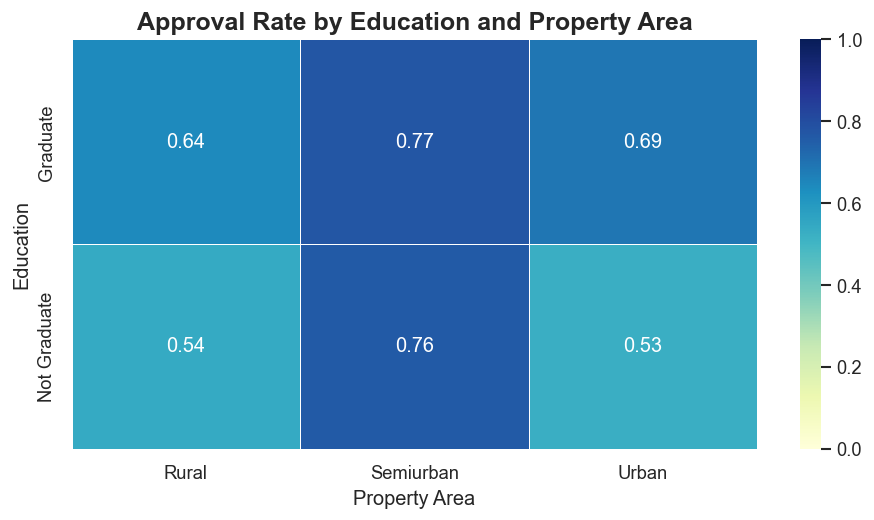

,Education,Property_Area,applications,approval_rate
1,Graduate,Semiurban,187,0.770
4,Not Graduate,Semiurban,46,0.761
2,Graduate,Urban,162,0.691
0,Graduate,Rural,131,0.641
3,Not Graduate,Rural,48,0.542
5,Not Graduate,Urban,40,0.525


In [9]:
segment_rates = (
    df.groupby(["Education", "Property_Area"])[target]
    .agg(applications="count", approval_rate="mean")
    .reset_index()
)

pivot_rates = segment_rates.pivot(index="Education", columns="Property_Area", values="approval_rate")

plt.figure(figsize=(8, 4.5))
sns.heatmap(pivot_rates, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, vmin=0, vmax=1)
plt.title("Approval Rate by Education and Property Area", fontsize=15, fontweight="bold")
plt.xlabel("Property Area")
plt.ylabel("Education")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task2_education_property_approval_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

segment_rates.sort_values("approval_rate", ascending=False).round(3)

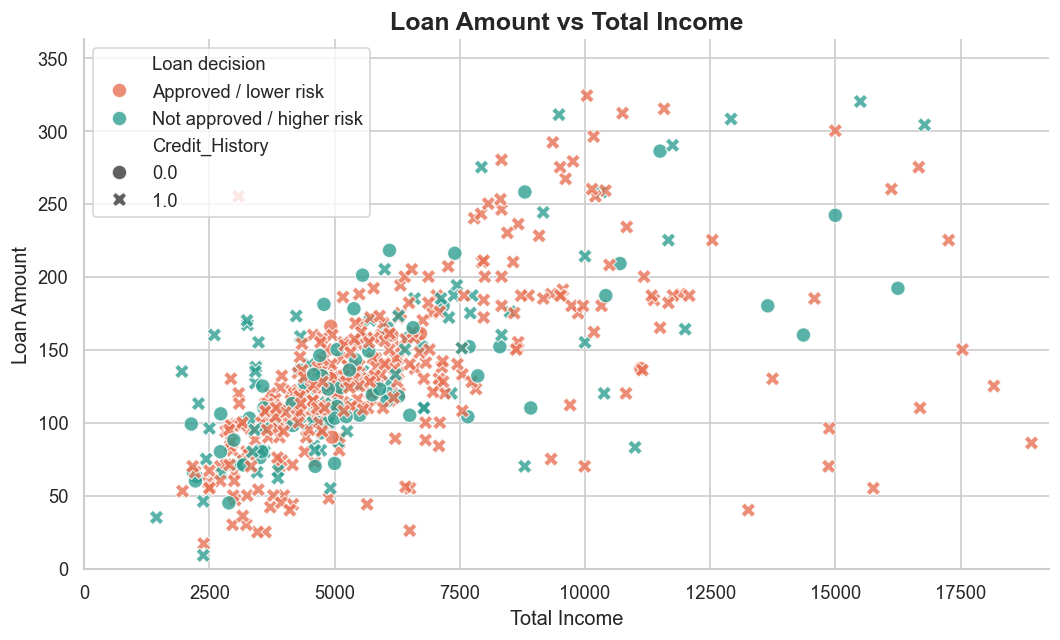

In [10]:
plt.figure(figsize=(9, 5.5))
sns.scatterplot(
    data=plot_df,
    x="TotalIncome",
    y="LoanAmount",
    hue="Loan decision",
    style="Credit_History",
    alpha=0.78,
    s=75,
    palette=["#E76F51", "#2A9D8F"],
)
plt.xlim(0, df["TotalIncome"].quantile(0.97))
plt.ylim(0, df["LoanAmount"].quantile(0.97))
plt.title("Loan Amount vs Total Income", fontsize=15, fontweight="bold")
plt.xlabel("Total Income")
plt.ylabel("Loan Amount")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task2_total_income_vs_loan_amount.png", dpi=180, bbox_inches="tight")
plt.show()

## Statistical Tests and Variable Meaning

In [11]:
test_rows = []

for col in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "TotalIncome", "LoanAmount_to_TotalIncome"]:
    approved = df.loc[df[target] == 1, col].dropna()
    not_approved = df.loc[df[target] == 0, col].dropna()
    stat, p_value = stats.mannwhitneyu(approved, not_approved, alternative="two-sided")
    test_rows.append(
        {
            "feature": col,
            "test": "Mann-Whitney U",
            "approved_median": approved.median(),
            "not_approved_median": not_approved.median(),
            "p_value": p_value,
        }
    )

for col in categorical_features:
    contingency = pd.crosstab(df[col], df[target])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency)
    test_rows.append(
        {
            "feature": col,
            "test": "Chi-square",
            "approved_median": np.nan,
            "not_approved_median": np.nan,
            "p_value": p_value,
        }
    )

test_table = pd.DataFrame(test_rows).sort_values("p_value")
test_table["p_value"] = test_table["p_value"].map(lambda value: f"{value:.3e}")
test_table.round(2)

,feature,test,approved_median,not_approved_median,p_value
10,Property_Area,Chi-square,NaN,NaN,2.136e-03
6,Married,Chi-square,NaN,NaN,3.439e-02
8,Education,Chi-square,NaN,NaN,4.310e-02
7,Dependents,Chi-square,NaN,NaN,3.679e-01
1,CoapplicantIncome,Mann-Whitney U,1239.50,268.00,3.869e-01
2,LoanAmount,Mann-Whitney U,126.00,129.00,3.952e-01
4,LoanAmount_to_TotalIncome,Mann-Whitney U,0.02,0.02,5.764e-01
5,Gender,Chi-square,NaN,NaN,7.087e-01
3,TotalIncome,Mann-Whitney U,5439.00,5289.50,7.128e-01
0,ApplicantIncome,Mann-Whitney U,3812.50,3833.50,9.181e-01


**Research note:** The statistical tests are used as evidence, not as decoration. Some variables show clearer differences than others. In this dataset, credit history and certain categorical segments tend to carry more signal than income alone. That is a useful warning against building a story where every column is treated as equally explanatory.

## Correlation and Multicollinearity Review

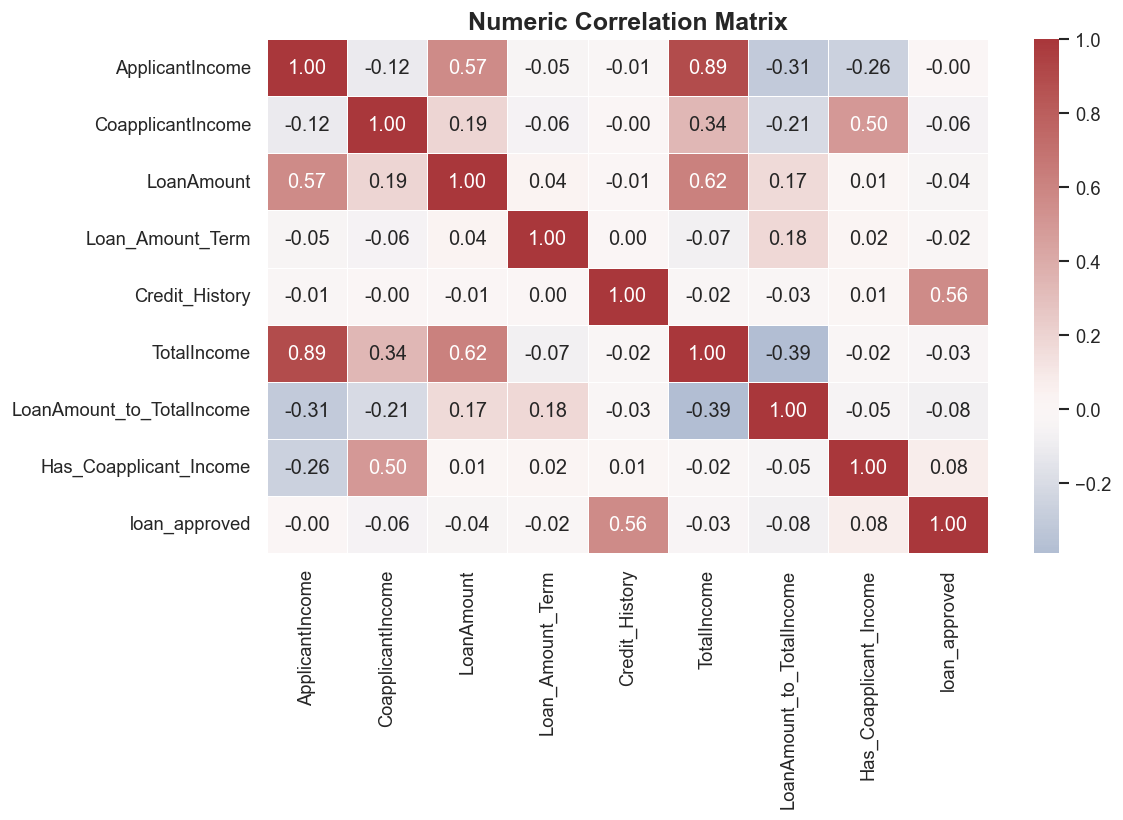

Credit_History               0.562
Has_Coapplicant_Income       0.075
ApplicantIncome             -0.005
Loan_Amount_Term            -0.021
TotalIncome                 -0.031
LoanAmount                  -0.037
CoapplicantIncome           -0.059
LoanAmount_to_TotalIncome   -0.077
Name: loan_approved, dtype: float64

In [12]:
corr_cols = engineered_numeric + [target]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5)
plt.title("Numeric Correlation Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task2_correlation_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

corr[target].drop(target).sort_values(ascending=False).round(3)

In [13]:
def calculate_vif(frame, columns):
    numeric = frame[columns].replace([np.inf, -np.inf], np.nan).dropna()
    numeric = numeric.loc[:, numeric.nunique() > 1]
    return (
        pd.DataFrame(
            {
                "feature": numeric.columns,
                "vif": [
                    variance_inflation_factor(numeric.values, i)
                    for i in range(numeric.shape[1])
                ],
            }
        )
        .sort_values("vif", ascending=False)
        .reset_index(drop=True)
    )

vif_table = calculate_vif(df, engineered_numeric)
vif_table.round(2)

,feature,vif
0,ApplicantIncome,inf
1,CoapplicantIncome,inf
2,TotalIncome,inf
3,Loan_Amount_Term,15.14
4,LoanAmount_to_TotalIncome,13.29
5,LoanAmount,9.35
6,Credit_History,5.80
7,Has_Coapplicant_Income,3.31


**Research note:** `TotalIncome` is engineered from applicant and coapplicant income, so it naturally overlaps with its components. That is useful for business interpretation but risky for coefficient interpretation. I keep the feature for the predictive model, while reading regression-style coefficients with caution.

## VADER Sentiment Applicability Check

In [14]:
text_columns = [
    col for col in df.columns
    if pd.api.types.is_object_dtype(df[col]) and df[col].nunique(dropna=True) > 20
]

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    vader_available = True
except ImportError:
    vader_available = False

vader_audit = pd.DataFrame(
    {
        "check": ["free_text_columns_available", "vader_package_available", "sentiment_model_used"],
        "result": [bool(text_columns), vader_available, bool(text_columns and vader_available)],
        "note": [
            f"Potential free-text columns: {text_columns}" if text_columns else "The dataset has categorical labels, not applicant comments or reviews.",
            "VADER is available for notebooks that include opinion text." if vader_available else "Install vaderSentiment before applying sentiment scoring.",
            "Not applied here because sentiment scores would be artificial for coded application fields.",
        ],
    }
)

vader_audit

,check,result,note
0,free_text_columns_available,False,"The dataset has categorical labels, not applic..."
1,vader_package_available,False,Install vaderSentiment before applying sentime...
2,sentiment_model_used,False,Not applied here because sentiment scores woul...


## Model Training: Regularized Logistic Regression

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, engineered_numeric),
        ("cat", categorical_transformer, categorical_features),
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

print(f"Baseline accuracy: {accuracy_score(y_test, baseline_pred):.3f}")
print(f"Baseline ROC AUC: {roc_auc_score(y_test, baseline_proba):.3f}")
print(classification_report(y_test, baseline_pred, target_names=["Not approved / higher risk", "Approved / lower risk"]))

Baseline accuracy: 0.862
Baseline ROC AUC: 0.867
                            precision    recall  f1-score   support

Not approved / higher risk       0.96      0.58      0.72        38
     Approved / lower risk       0.84      0.99      0.91        85

                  accuracy                           0.86       123
                 macro avg       0.90      0.78      0.81       123
              weighted avg       0.88      0.86      0.85       123



In [16]:
param_grid = {
    "classifier__C": [0.01, 0.05, 0.1, 0.5, 1, 5, 10],
    "classifier__class_weight": [None, "balanced"],
}

tuned_search = GridSearchCV(
    baseline_model,
    param_grid=param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,
)

tuned_search.fit(X_train, y_train)
tuned_model = tuned_search.best_estimator_
tuned_pred = tuned_model.predict(X_test)
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]

print("Best parameters:", tuned_search.best_params_)
print(f"Tuned accuracy: {accuracy_score(y_test, tuned_pred):.3f}")
print(f"Tuned ROC AUC: {roc_auc_score(y_test, tuned_proba):.3f}")
print(f"Tuned average precision: {average_precision_score(y_test, tuned_proba):.3f}")
print(classification_report(y_test, tuned_pred, target_names=["Not approved / higher risk", "Approved / lower risk"]))

Best parameters: {'classifier__C': 0.01, 'classifier__class_weight': None}
Tuned accuracy: 0.854
Tuned ROC AUC: 0.868
Tuned average precision: 0.923
                            precision    recall  f1-score   support

Not approved / higher risk       0.95      0.55      0.70        38
     Approved / lower risk       0.83      0.99      0.90        85

                  accuracy                           0.85       123
                 macro avg       0.89      0.77      0.80       123
              weighted avg       0.87      0.85      0.84       123



## Evaluation and Decision Tradeoff

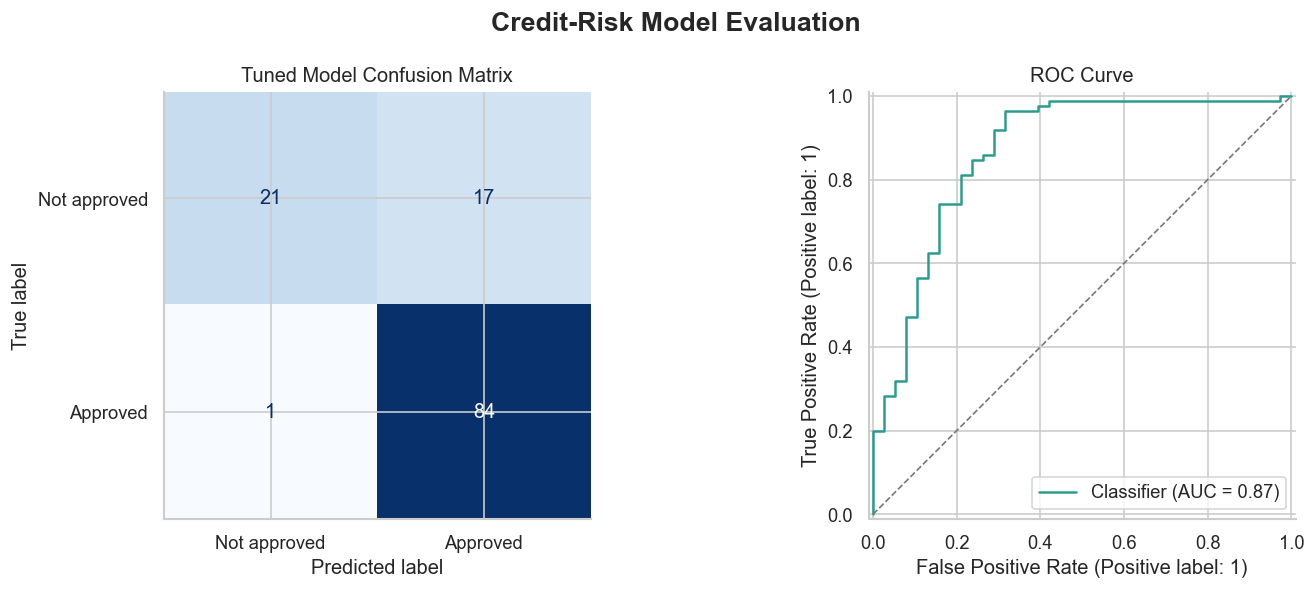

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_pred,
    display_labels=["Not approved", "Approved"],
    cmap="Blues",
    values_format="d",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Tuned Model Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, tuned_proba, ax=axes[1], color="#2A9D8F")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="#777777", linewidth=1)
axes[1].set_title("ROC Curve")

fig.suptitle("Credit-Risk Model Evaluation", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "task2_model_confusion_and_roc.png", dpi=180, bbox_inches="tight")
plt.show()

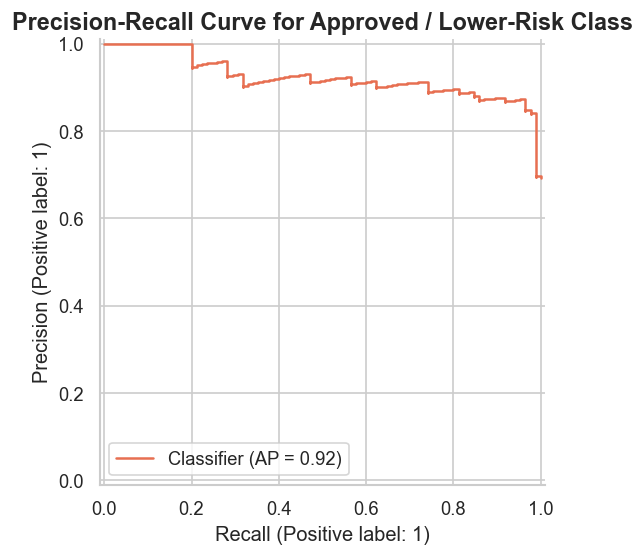

In [18]:
PrecisionRecallDisplay.from_predictions(y_test, tuned_proba, color="#E76F51")
plt.title("Precision-Recall Curve for Approved / Lower-Risk Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task2_precision_recall_curve.png", dpi=180, bbox_inches="tight")
plt.show()

In [19]:
threshold_rows = []
for threshold in np.arange(0.30, 0.76, 0.05):
    threshold_pred = (tuned_proba >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": round(threshold, 2),
            "accuracy": accuracy_score(y_test, threshold_pred),
            "precision_approved": precision_score(y_test, threshold_pred, zero_division=0),
            "recall_approved": recall_score(y_test, threshold_pred, zero_division=0),
            "f1_approved": f1_score(y_test, threshold_pred, zero_division=0),
            "predicted_approval_rate": threshold_pred.mean(),
        }
    )

threshold_table = pd.DataFrame(threshold_rows).round(3)
threshold_table

,threshold,accuracy,precision_approved,recall_approved,f1_approved,predicted_approval_rate
0,0.30,0.691,0.691,1.000,0.817,1.000
1,0.35,0.724,0.718,0.988,0.832,0.951
2,0.40,0.821,0.800,0.988,0.884,0.854
3,0.45,0.854,0.832,0.988,0.903,0.821
4,0.50,0.854,0.832,0.988,0.903,0.821
5,0.55,0.862,0.840,0.988,0.908,0.813
6,0.60,0.862,0.840,0.988,0.908,0.813
7,0.65,0.862,0.840,0.988,0.908,0.813
8,0.70,0.846,0.867,0.918,0.891,0.732
9,0.75,0.585,0.925,0.435,0.592,0.325


In [20]:
cv_results = cross_validate(
    tuned_model,
    X,
    y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
)

pd.DataFrame(
    {
        metric.replace("test_", ""): [values.mean(), values.std()]
        for metric, values in cv_results.items()
        if metric.startswith("test_")
    },
    index=["mean", "std"],
).round(3)

,accuracy,precision,recall,f1,roc_auc
mean,0.806,0.791,0.976,0.874,0.778
std,0.022,0.017,0.015,0.015,0.033


**Research note:** In lending, the threshold is a business decision. A lower threshold approves more people but can increase risky approvals. A higher threshold is more conservative but may reject applicants who could have been acceptable. I included the threshold table so the model is not treated as a single magic answer.

## Model Explanation: Direction of Predictive Signal

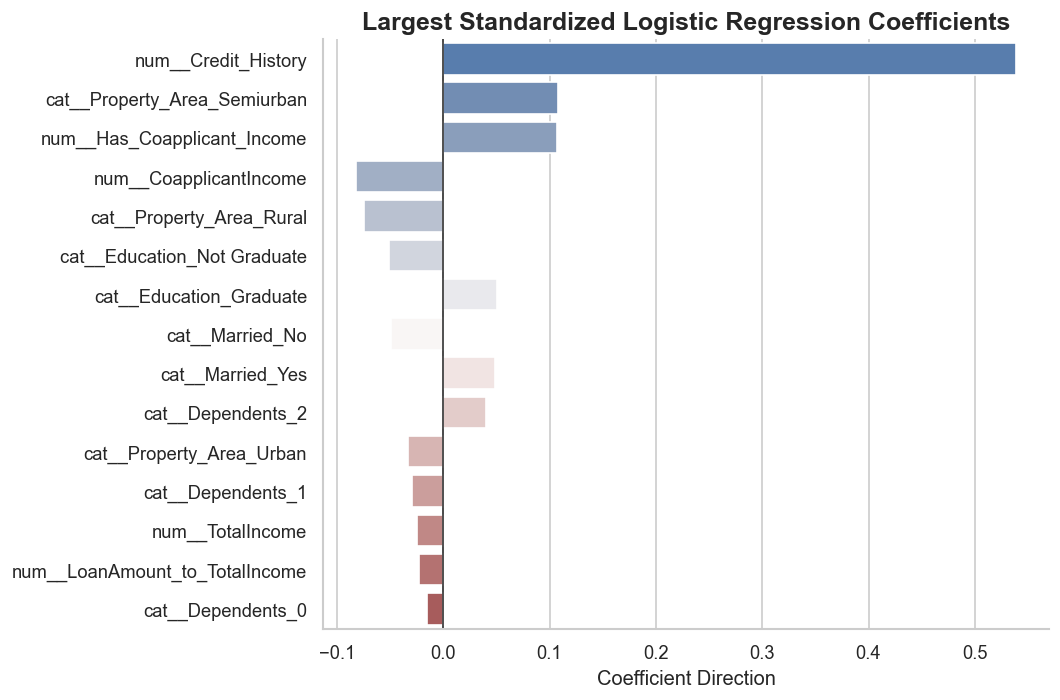

,feature,coefficient
4,num__Credit_History,0.539
21,cat__Property_Area_Semiurban,0.108
7,num__Has_Coapplicant_Income,0.107
1,num__CoapplicantIncome,-0.082
20,cat__Property_Area_Rural,-0.074
17,cat__Education_Not Graduate,-0.051
16,cat__Education_Graduate,0.051
10,cat__Married_No,-0.049
11,cat__Married_Yes,0.049
14,cat__Dependents_2,0.041


In [21]:
feature_names = tuned_model.named_steps["preprocess"].get_feature_names_out()
coefs = tuned_model.named_steps["classifier"].coef_[0]

coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefs})
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
sns.barplot(data=coef_df, x="coefficient", y="feature", palette="vlag")
plt.axvline(0, color="#333333", linewidth=1)
plt.title("Largest Standardized Logistic Regression Coefficients", fontsize=15, fontweight="bold")
plt.xlabel("Coefficient Direction")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "task2_logistic_coefficients.png", dpi=180, bbox_inches="tight")
plt.show()

coef_df.drop(columns="abs_coefficient").round(3)

## Final Findings

1. The dataset is usable but has missing values in important application fields, especially credit history and loan amount. Imputation is necessary before modeling.
2. The target is approval status, so the notebook frames the analysis as approval/lower-risk versus not-approved/higher-risk instead of claiming direct default prediction.
3. Credit history is the strongest practical signal in the visible analysis. Income and loan amount help, but they do not explain the decision by themselves.
4. Engineered income features improve the business view, but multicollinearity means coefficient interpretation must be careful.
5. VADER sentiment analysis is not applied because there is no free-text applicant feedback field. The correct use here is an applicability audit, not artificial sentiment scoring.
6. Regularized logistic regression is appropriate as a transparent baseline. The model should be judged with confusion matrix, ROC AUC, precision-recall behavior, and threshold tradeoffs rather than accuracy alone.